# L1.2 — The frame and the geometry

**Level 1 · Depth · 40 minutes**

**Goal.** You can calculate a bearing, a distance, and a relative state.

**Check at the end.** You can say why the minimum separation inside one step can be smaller than the
distance at both ends of that step.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. The two frames

The library stores a position as `lat` and `lon` in degrees. It does the geometry in metres, in a
local east/north plane. Two modules do the work:

| Module | Use it for |
| --- | --- |
| `opencdarr.geo` | Positions: a bearing, a distance, a destination, a local plane. |
| `opencdarr.relative` | Pairs: the relative position and velocity, and the separation. |

Four functions in `geo`, and you need all four:

```python
geo.earth_radius(lat)                       # the local WGS84 radius [m]
geo.forward(lat, lon, bearing, dist)        # -> (lat, lon) at that bearing and distance
geo.qdrdist(lat1, lon1, lat2, lon2)         # -> (bearing [deg], distance [m])
geo.enu(origin_lat, origin_lon, lat, lon)   # -> (east, north) [m] from the origin
```

Angles use the aviation convention: 0 is north, and the angle increases clockwise. This is not the
mathematical convention, so do not use `atan2(y, x)` on these numbers without a conversion.

In [1]:
import dataclasses

import numpy as np

from opencdarr import M600, create_aircraft, create_conflict, geo

print(f"earth radius at 52 N   {geo.earth_radius(52.0):,.0f} m")
print(f"earth radius at  0 N   {geo.earth_radius(0.0):,.0f} m")

# move 1000 m north from a point, then measure the way back
start = (52.0, 4.0)
north = geo.forward(*start, 0.0, 1000.0)
bearing, distance = geo.qdrdist(*start, *north)

print(f"\nstart              {start[0]:.6f}, {start[1]:.6f}")
print(f"1000 m to the north {north[0]:.6f}, {north[1]:.6f}")
print(f"measured back       bearing {bearing:.3f} deg, distance {distance:.3f} m")

# the same point as east/north metres from the start
east_m, north_m = geo.enu(*start, *north)
print(f"as east/north       {east_m:.3f} m east, {north_m:.3f} m north")

earth radius at 52 N   6,364,900 m
earth radius at  0 N   6,378,137 m

start              52.000000, 4.000000
1000 m to the north 52.009002, 4.000000
measured back       bearing 0.000 deg, distance 1000.000 m
as east/north       0.000 m east, 1000.000 m north


`qdrdist` is the exact inverse of `forward`, so a round trip returns the bearing and the distance
that you gave. Use that as a check whenever you write your own geometry.

`enu` is `qdrdist` resolved into components. Use it to draw a track, and to test whether a point is
inside a measurement area.

In [2]:
# a round trip over four bearings, to prove the inverse
print(f"{'bearing in':>11}{'distance in':>13}{'bearing out':>13}{'distance out':>14}")
for brg in (0.0, 45.0, 137.0, 300.0):
    p = geo.forward(*start, brg, 2500.0)
    b_out, d_out = geo.qdrdist(*start, *p)
    print(f"{brg:>11.1f}{2500.0:>13.1f}{b_out:>13.6f}{d_out:>14.6f}")

 bearing in  distance in  bearing out  distance out
        0.0       2500.0     0.000000   2500.000000
       45.0       2500.0    45.000000   2500.000000
      137.0       2500.0   137.000000   2500.000000
      300.0       2500.0   300.000000   2500.000000


## 2. The relative state of a pair

`relative_enu(own, intr)` gives you the intruder **as seen from the ownship**: its position and its
velocity, both relative, both in east/north metres.

```python
Relative(rx, ry, vx, vy)     # position [m] and velocity [m/s], intruder minus ownship
r.dist                       # the current range [m]
```

Every conflict algorithm in this library works from these four numbers. `velocity_enu(state)` gives
one aircraft's velocity on its own, if you need it.

In [3]:
from opencdarr.relative import relative_enu, segment_min_range, velocity_enu

own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=15.0)
intr = create_conflict(own, intr_id="INT", dpsi=90.0, dcpa=20.0, tlos=60.0, rpz=50.0, gs_intr=15.0)

r = relative_enu(own, intr)
print(f"own velocity    east {velocity_enu(own)[0]:7.2f}  north {velocity_enu(own)[1]:7.2f}  m/s")
print(f"intr velocity   east {velocity_enu(intr)[0]:7.2f}  north {velocity_enu(intr)[1]:7.2f}  m/s")
print()
print(f"relative position   rx {r.rx:8.1f} m    ry {r.ry:8.1f} m")
print(f"relative velocity   vx {r.vx:8.2f} m/s  vy {r.vy:8.2f} m/s")
print(f"range now           {r.dist:.1f} m")

own velocity    east    0.00  north   15.00  m/s
intr velocity   east   15.00  north    0.00  m/s

relative position   rx   -918.3 m    ry    946.5 m
relative velocity   vx    15.00 m/s  vy   -15.00 m/s
range now           1318.8 m


## 3. Move an aircraft without a kinematics model

To study the geometry alone, move a state along its own track with `geo.forward`. This is not a
flight model. It has no limits and no dynamics, and it is enough for this lesson.

In [4]:
def at(state, t: float):
    """The state moved along its own track for t seconds. Geometry only, no dynamics."""
    lat, lon = geo.forward(state.lat, state.lon, state.trk, state.gs * t)
    return dataclasses.replace(state, lat=lat, lon=lon)


for t in (0.0, 30.0, 60.0, 90.0):
    print(f"t = {t:5.0f} s   range {relative_enu(at(own, t), at(intr, t)).dist:8.1f} m")

t =     0 s   range   1318.8 m
t =    30 s   range    682.5 m
t =    60 s   range     49.8 m
t =    90 s   range    591.1 m


## 4. Measure the minimum inside a step, not at its ends

A simulation samples the state every `dt`. If you read the range only at those samples, you can miss
the closest point completely: the pair dips inside a threshold and comes back out between two
samples, and no sample lands inside.

The error is **one-sided**. Endpoint sampling can only report a minimum that is too large. It never
reports one that is too small. So it makes the encounter look safer than it was.

`segment_min_range(r0, r1)` closes the gap. Give it the relative state at both ends of a step. It
returns the smallest range on the straight segment between them.

It interpolates the **positions**. It does not extrapolate the velocity of `r0`. A velocity
extrapolation leaves the flown path as soon as an aircraft turns, and it can report a range at a
point the aircraft never reached.

In [5]:
def scan(dt: float, t_max: float = 120.0) -> tuple[float, float]:
    """(the endpoint minimum, the segment minimum) over the encounter, at this step size."""
    times = np.arange(0.0, t_max + 1e-9, dt)
    rels = [relative_enu(at(own, t), at(intr, t)) for t in times]
    endpoints = min(r.dist for r in rels)
    segments = min(segment_min_range(a, b) for a, b in zip(rels[:-1], rels[1:]))
    return endpoints, segments


truth = scan(0.01)[0]          # a step small enough to be the reference
print(f"reference minimum (dt = 0.01 s)   {truth:.3f} m\n")
print(f"{'dt [s]':>7}{'endpoints only':>17}{'segment':>11}{'endpoint error':>17}")
for dt in (1.0, 2.0, 5.0, 10.0, 20.0):
    ends, seg = scan(dt)
    print(f"{dt:>7.1f}{ends:>17.3f}{seg:>11.3f}{ends - truth:>+17.3f}")

reference minimum (dt = 0.01 s)   19.879 m

 dt [s]   endpoints only    segment   endpoint error
    1.0           20.147     19.879           +0.268
    2.0           20.147     19.879           +0.268
    5.0           49.845     19.879          +29.966
   10.0           49.845     19.879          +29.966
   20.0           49.845     19.879          +29.966


Read the `dt = 5` row against a protected zone of 50 m. Endpoint sampling reports about 50 m, so it
calls the encounter clear. The segment method reports about 20 m, so it calls it a loss. The two
disagree about the result of the run, not only about a decimal.

The relative error of endpoint sampling grows as

$$\frac{(v_\text{rel}\,\Delta t)^2}{24\,d^2}$$

so it is harmless next to a 50 m protected zone and severe at the small radii that a rare-event
estimator splits on. Lesson L6.3 is where this matters most.

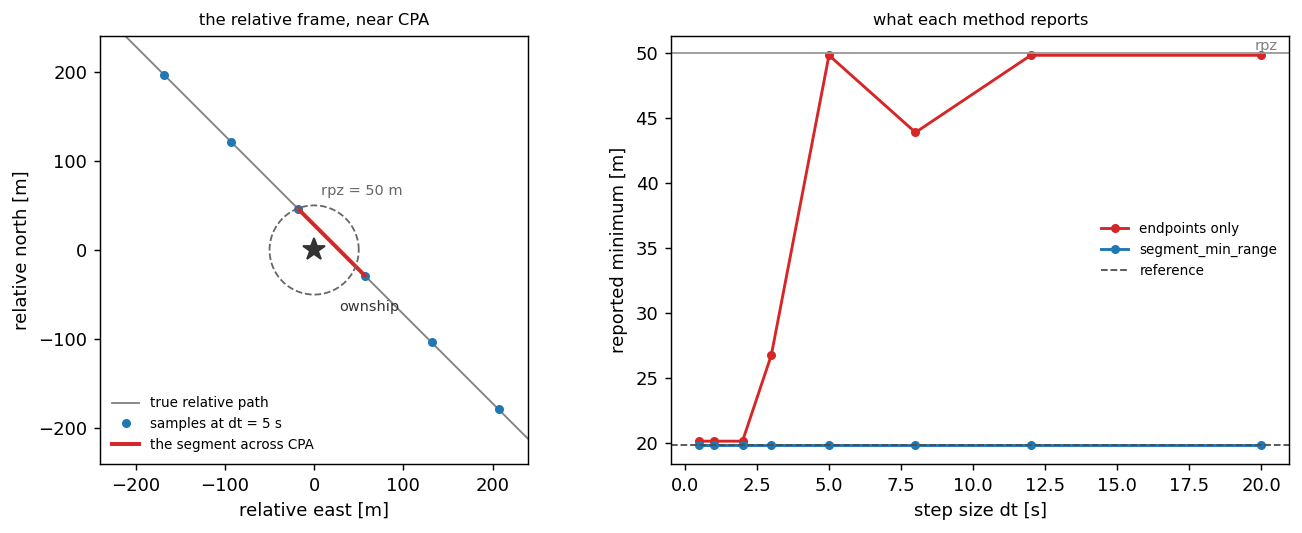

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY = "#1f77b4", "#d62728", "#7f7f7f"

DT = 5.0
times = np.arange(0.0, 120.0 + 1e-9, DT)
rels = [relative_enu(at(own, t), at(intr, t)) for t in times]
pairs = list(zip(rels[:-1], rels[1:]))
k = int(np.argmin([segment_min_range(a, b) for a, b in pairs]))   # the step that straddles CPA
r0, r1 = pairs[k]

fine = [relative_enu(at(own, t), at(intr, t)) for t in np.arange(0.0, 120.0, 0.25)]

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(10.6, 4.2))

ax_a.plot([r.rx for r in fine], [r.ry for r in fine], lw=1.0, color=GREY, label="true relative path")
ax_a.plot([r.rx for r in rels], [r.ry for r in rels], ls="none", marker="o", ms=4, color=BLUE,
          label=f"samples at dt = {DT:.0f} s")
ax_a.plot([r0.rx, r1.rx], [r0.ry, r1.ry], lw=2.2, color=RED, label="the segment across CPA")
ax_a.plot(0, 0, marker="*", ms=13, color="0.2")
ax_a.annotate("ownship", (0, 0), (14, -34), textcoords="offset points", fontsize=8, color="0.2")
theta = np.linspace(0, 2 * np.pi, 240)
ax_a.plot(50.0 * np.cos(theta), 50.0 * np.sin(theta), ls="--", lw=1.0, color="0.4")
ax_a.annotate("rpz = 50 m", (0, 50), (4, 6), textcoords="offset points", fontsize=8, color="0.4")
ax_a.set_aspect("equal")
ax_a.set_xlim(-240, 240)          # zoom on the closest approach; the path runs off both corners
ax_a.set_ylim(-240, 240)
ax_a.set_xlabel("relative east [m]")
ax_a.set_ylabel("relative north [m]")
ax_a.set_title("the relative frame, near CPA", fontsize=9)
ax_a.legend(frameon=False, fontsize=7.5, loc="lower left")

dts = np.array([0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0])
ends = [scan(d)[0] for d in dts]
segs = [scan(d)[1] for d in dts]
ax_b.plot(dts, ends, marker="o", ms=4, lw=1.6, color=RED, label="endpoints only")
ax_b.plot(dts, segs, marker="o", ms=4, lw=1.6, color=BLUE, label="segment_min_range")
ax_b.axhline(truth, ls="--", lw=1.0, color="0.3", label="reference")
ax_b.axhline(50.0, lw=1.0, color="0.6")
ax_b.annotate("rpz", (0.98, 50.0), xycoords=("axes fraction", "data"), ha="right", va="bottom",
              fontsize=8, color="0.5")
ax_b.set_xlabel("step size dt [s]")
ax_b.set_ylabel("reported minimum [m]")
ax_b.set_title("what each method reports", fontsize=9)
ax_b.legend(frameon=False, fontsize=7.5)
fig.tight_layout()

## 5. The same measurement for a fleet

Four helpers scale the pair case to N aircraft. They all walk the pairs in the same fixed order,
`i < j`, so you can index one result with another.

| Function | What it gives |
| --- | --- |
| `pair_ids(n)` | The pair order: `((0,1), (0,2), (1,2), ...)`. |
| `pairwise_relative(states)` | One `Relative` for each pair, at this instant. |
| `pairwise_min_sep(states)` | The smallest range over all pairs, at this instant. |
| `pair_min_ranges(pre, post)` | Each pair's minimum across a step. |
| `segment_min_sep(pre, post)` | The smallest of those — one number for the step. |

`pair_min_ranges` keeps the whole vector, so the runner can name **which** pairs crossed the
protected zone. That is where the counts `K` and `A` of lesson L3.3 come from.

In [7]:
from opencdarr.relative import (
    pair_ids,
    pair_min_ranges,
    pairwise_min_sep,
    pairwise_relative,
    segment_min_sep,
)

third = create_conflict(own, intr_id="THIRD", dpsi=225.0, dcpa=120.0, tlos=45.0, rpz=50.0,
                        gs_intr=12.0)
fleet = [own, intr, third]
ids = [s.id for s in fleet]

T0, T1 = 55.0, 65.0                          # one long step, with the closest approach inside it
pre = pairwise_relative([at(s, T0) for s in fleet])
post = pairwise_relative([at(s, T1) for s in fleet])
ranges = pair_min_ranges(pre, post)

print(f"{'pair':<16}{'at t=55 s':>12}{'at t=65 s':>12}{'across the step':>18}")
for (i, j), a, b, m in zip(pair_ids(len(fleet)), pre, post, ranges):
    print(f"{ids[i] + '-' + ids[j]:<16}{a.dist:>12.1f}{b.dist:>12.1f}{m:>18.1f}")

ends = min(pairwise_min_sep([at(s, T0) for s in fleet]),
           pairwise_min_sep([at(s, T1) for s in fleet]))
print(f"\nsmallest at the two ends     {ends:.1f} m")
print(f"smallest across the step     {segment_min_sep(pre, post):.1f} m")

pair               at t=55 s   at t=65 s   across the step
OWN-INT                153.1        63.6              19.9
OWN-THIRD              277.1       513.7             277.1
INT-THIRD              415.2       495.1             415.2

smallest at the two ends     63.6 m
smallest across the step     19.9 m


## Do it yourself

1. Change `dcpa` in section 2 from 20 m to 0 m. Run section 4 again. Compare the endpoint error.
2. Increase both ground speeds to 25 m/s. The relative speed doubles. Check the error against the
   $(v_\text{rel}\Delta t)^2$ rule.
3. Add a fourth aircraft to section 5. Count the pairs before you run it.

## Check

1. Why can the minimum separation inside one step be smaller than the distance at both ends of it?
2. The endpoint error is one-sided. In which direction, and why does that direction matter for a
   safety claim?
3. Why does `segment_min_range` interpolate the positions instead of extrapolating the velocity?

## Next

`L1.3 — The performance envelope`. You can measure the geometry. Next you describe what an airframe
is able to do.